SOLO - S-ADCP transect

DOPPIOE - Numerical

LATTE - drifter, drifter and sattellite (multimodel) 

Keep it simple, be like water, flow

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import xarray as xr
import scipy.io as sio
from datetime import datetime, timedelta

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q, tangential_velocity


In [2]:
def latte(xi, yi, ui, vi):
    from scipy.optimize import least_squares
    xi, yi, ui, vi = map(lambda a: np.asarray(a, float), (xi, yi, ui, vi))
    m = np.isfinite(xi) & np.isfinite(yi) & np.isfinite(ui) & np.isfinite(vi)
    x, y, u_i, v_i = xi[m], yi[m], ui[m], vi[m]
    n = x.size
    if n < 3:
        return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan, np.nan

    p0 = np.array([x.mean(), y.mean(), 1., 0., 1.])  # xc,yc,Oq11,Oq12,Oq22

    def fun(p):
        xc,yc,Oq11,Oq12,Oq22 = p
        dx, dy = x-xc, y-yc
        u = -Oq22*dy - Oq12*dx
        v =  Oq11*dx + Oq12*dy
        r = np.empty(2*n); r[:n]=u-u_i; r[n:]=v-v_i
        return r

    def jac(p):
        xc,yc,Oq11,Oq12,Oq22 = p
        dx, dy = x-xc, y-yc
        J = np.zeros((2*n,5))
        # u = -Omega*q22*(y-yc) - Omega*q12*(x-xc)
        J[:n,0], J[:n,1], J[:n,3], J[:n,4] = Oq12, Oq22, -dx, -dy
        # v = Omega*q11*(x-xc) + Omega*q12*(y-yc)
        J[n:,0], J[n:,1], J[n:,2], J[n:,3] = -Oq11, -Oq12, dx, dy
        return J

    xc,yc,Oq11,Oq12,Oq22 = least_squares(fun, p0, jac=jac).x

    dx, dy = x-xc, y-yc
    u = -Oq22*dy - Oq12*dx
    v =  Oq11*dx + Oq12*dy
    err2 = ((u-u_i)**2 + (v-v_i)**2).sum()
    tot2 = ((u_i-u_i.mean())**2 + (v_i-v_i.mean())**2).sum()
    r2 = 1 - err2/tot2 if tot2 > 0 else np.nan

    w = Oq11+Oq22
    OQ = np.array([[Oq11,Oq12],[Oq12,Oq22]])
    det = OQ[0,0]*OQ[1,1] - OQ[0,1]*OQ[1,0]
    Omega = np.sign(Oq11)*np.sqrt(abs(det))
    Q = OQ/Omega if Omega != 0 else np.full((2,2), np.nan)

    return xc, yc, w, Q, Omega, r2

def out_core_param_fit(
    rho2, Qr, vt,
    Omega0=None, Rc0=None,
    plot=False, ax=None,
    maxfev=10000, Rc_max=1e5,
    r2_flag=False,
    rho_plot_max=None, n_curve=400,
    km_flag=False,
    ci_flag=False,
    pred_flag=False
):

    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]
    Qr   = Qr[m]
    vt   = vt[m]

    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(r2, Omega, Rc):
        return Omega * np.sqrt(r2) * np.exp(-r2 / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]

    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2), 1e-6)

    if Omega0 is None:
        denom = rho * np.exp(-rho2 / (Rc0**2))
        ok = np.abs(denom) > 0
        Omega0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0

    if not np.isfinite(Omega0):
        Omega0 = 0

    pcov = None
    try:
        popt, pcov = curve_fit(
            vt_model, rho2, vt,
            p0=[Omega0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        Omega_opt, Rc_opt = popt
    except:
        Omega_opt, Rc_opt = Omega0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        Omega_opt, Rc_opt = Omega0, Rc0
        pcov = None

    psi0_opt = -0.5 * Omega_opt * Rc_opt**2

    vt_fit = vt_model(rho2, Omega_opt, Rc_opt)

    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    dof = max(len(vt) - 2, 1)
    sigma2 = ss_res / dof

    if plot:

        if ax is None:
            fig, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = np.nanmax(rho)

        r_grid = np.linspace(0, rho_plot_max, n_curve)
        r2_grid = r_grid**2

        vt_grid = vt_model(r2_grid, Omega_opt, Rc_opt)

        if km_flag:
            core_mask = rho <= 30
        else:
            core_mask = rho <= 30_000

        ax.scatter(rho[core_mask], np.abs(vt[core_mask]), s=10, color='m', label='Core observed')
        ax.scatter(rho[~core_mask], np.abs(vt[~core_mask]), s=10, color='g', label='Outer-core observed')

        ax.plot(r_grid, np.abs(vt_grid), lw=2, color='b', label='')
        ax.axvline(Rc_opt / np.sqrt(2), ls='--', color='r', label='', lw=2)

        if pcov is not None:

            exp_term = np.exp(-r2_grid / (Rc_opt**2))

            dOmega = np.sqrt(r2_grid) * exp_term
            dRc = 2 * Omega_opt * (r2_grid**1.5) * exp_term / (Rc_opt**3)

            J = np.vstack([dOmega, dRc]).T
            var_model = np.einsum("ij,jk,ik->i", J, pcov, J)

            if ci_flag:
                se_model = np.sqrt(np.maximum(var_model, 0))
                lo = vt_grid - 1.96 * se_model
                hi = vt_grid + 1.96 * se_model

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='orange', alpha=.2, label='95% CI'
                )

            if pred_flag:
                se_pred = np.sqrt(np.maximum(var_model + sigma2, 0))
                lo = vt_grid - 1.96 * se_pred
                hi = vt_grid + 1.96 * se_pred

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='b', alpha=.15, label=''
                )

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')

        ax.set_title(
            f"Omega={Omega_opt:.3g}, Rc={Rc_opt:.3g}, psi0={psi0_opt:.3g}, R²={R2:.2f}"
        )

        ax.legend()

    return (Rc_opt, psi0_opt, Omega_opt, R2) if r2_flag else (Rc_opt, psi0_opt, Omega_opt)
    

### SADCP Data

In [3]:
sad = sio.loadmat('/srv/scratch/z5297792/ESP_Paper_Data/sadcp_data_CCE_2023.mat', simplify_cells=True)

z = sad['z_sadcp']
ref = datetime(2000,1,1,12)
time = np.array([ref + timedelta(days=jd-2451545.0) for jd in sad['tim_sadcp']], dtype='datetime64[ns]')

df = pd.DataFrame({
    "Time": time,
    "Lon": sad['lon_sadcp'],
    "Lat": sad['lat_sadcp']
})

df = pd.concat([
    df,
    pd.DataFrame(sad['u_sadcp'], index=[f'u_{zv}' for zv in z]).T,
    pd.DataFrame(sad['v_sadcp'], index=[f'v_{zv}' for zv in z]).T
], axis=1)

df = df[df.Lat <= -37].reset_index(drop=True)

theta_mean, phi_mean = 154.3, -37.9
df["x"] = (df.Lon-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
df["y"] = (df.Lat-phi_mean)*111000

ds_sadcp = xr.Dataset(
    {"u": (("time","z"), df[[f"u_{zz}" for zz in z]].to_numpy()),
     "v": (("time","z"), df[[f"v_{zz}" for zz in z]].to_numpy())},
    coords={
        "time": df.Time.values,
        "z": z,
        "lon": ("time", df.Lon.values),
        "lat": ("time", df.Lat.values),
        "x": ("time", df.x.values),
        "y": ("time", df.y.values),
    }
)

ds_sadcp


<xarray.Dataset> Size: 565kB
Dimensions:  (time: 433, z: 79)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2023-10-17T10:27:31.000004 ... 2023-10...
  * z        (z) uint16 158B 27 37 47 57 67 77 87 ... 757 767 777 787 797 807
    lon      (time) float64 3kB 154.4 154.4 154.4 154.4 ... 154.2 154.2 154.2
    lat      (time) float64 3kB -37.01 -37.04 -37.07 ... -37.09 -37.06 -37.03
    x        (time) float64 3kB 4.998e+03 5.326e+03 ... -1.057e+04 -1.057e+04
    y        (time) float64 3kB 9.932e+04 9.567e+04 ... 9.343e+04 9.673e+04
Data variables:
    u        (time, z) float64 274kB nan 0.5344 0.569 0.5493 ... nan nan nan nan
    v        (time, z) float64 274kB nan -0.05262 0.006571 ... nan nan nan

### Satellite Data

In [4]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_IMOS_drifters.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['LONGITUDE'][:].data, ds_nc['LATITUDE'][:].data
u, v = ds_nc['UCUR'][:].data, ds_nc['VCUR'][:].data

t = pd.Timestamp("1985-01-01 00:00:00", tz="UTC") + pd.to_timedelta(ds_nc['TIME'][:].data, "D")
t = pd.DatetimeIndex(t).tz_convert(None)

u, v = np.where(np.abs(u) < 4.9, u, np.nan), np.where(np.abs(v) < 4.9, v, np.nan)

ds = xr.Dataset(
    {"u": (("time","lat","lon"), u), "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon},
)

theta_mean, phi_mean = np.float64(154.3), np.float64(-37.9)
lon2d, lat2d = np.meshgrid(lon, lat)
ds = ds.assign_coords(
    x=(("lat","lon"), (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))),
    y=(("lat","lon"), (lat2d-phi_mean)*111000),
)

t0, t1 = ds.time.to_index()[0], ds.time.to_index()[-1]
start = t0.normalize() + pd.Timedelta(hours=6) + pd.Timedelta(days=int(t0 > t0.normalize() + pd.Timedelta(hours=6)))
end   = t1.normalize() + pd.Timedelta(hours=6) - pd.Timedelta(days=int(t1 < t1.normalize() + pd.Timedelta(hours=6)))
t6am = pd.date_range(start, end, freq="1D")

ds_sat = ds.interp(time=t6am)

# Find land mask
land_mask = np.isnan(ds.u.isel(time=0)) & np.isnan(ds.v.isel(time=0))  # (lat, lon)
ds = ds.assign(land_mask=land_mask)
ds_sat = ds_sat.assign(land_mask=land_mask)

# # Time slice
ds_sat = ds_sat.sel(time=ds_sat.time <= np.datetime64('2024-01-27T06:00:00.000000000'))

ds_sat


<xarray.Dataset> Size: 3MB
Dimensions:    (time: 101, lat: 41, lon: 46)
Coordinates:
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
  * time       (time) datetime64[ns] 808B 2023-10-19T06:00:00 ... 2024-01-27T...
Data variables:
    u          (time, lat, lon) float64 2MB -0.165 -0.2501 ... 0.2664 0.3238
    v          (time, lat, lon) float64 2MB -0.1421 -0.1373 ... -0.4036 -0.314
    land_mask  (lat, lon) bool 2kB False False False False ... False False False

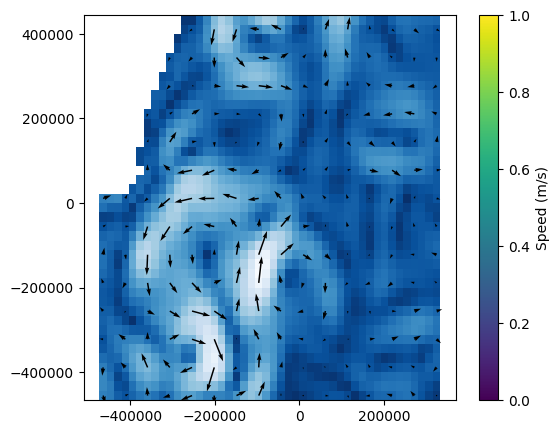

In [5]:
t = '2024-01-21T06:00:00'

u = ds_sat.u.sel(time=t)
v = ds_sat.v.sel(time=t)
speed = np.sqrt(u**2 + v**2)

plt.figure(figsize=(6,5))
plt.pcolormesh(ds_sat.x, ds_sat.y, speed, shading='auto', cmap='Blues_r')

spac = 3
plt.quiver(
    ds_sat.x.values[::spac, ::spac],
    ds_sat.y.values[::spac, ::spac],
    u.values[::spac, ::spac],
    v.values[::spac, ::spac],
    scale=15
)

plt.colorbar(label='Speed (m/s)')
plt.axis('equal')
plt.show()


In [6]:
def latte_source_selector(source="multi", z_target=37.0, plot=False):
    xc_pre, yc_pre = 0.0, 0.0
    q11, q12, q22 = 1.0, 0.0, 1.0
    rho_core, rho_outer = 35_000.0, 100_000.0

    # t_mean = ds_sadcp.time.mean().values
    # time = ds_sat.time.sel(time=t_mean, method="nearest").values

    # X, Y = ds_sat.x.values, ds_sat.y.values
    # xg, yg = X.ravel(), Y.ravel()
    # ut, vt = ds_sat.u.sel(time=time).values.ravel(), ds_sat.v.sel(time=time).values.ravel()

    ##### interpolate to this time ################
    t_mean = ds_sadcp.time.mean().values
    
    X, Y = ds_sat.x.values, ds_sat.y.values
    xg, yg = X.ravel(), Y.ravel()
    
    sat_interp = ds_sat.interp(time=t_mean)
    
    ut = sat_interp.u.values.ravel()
    vt = sat_interp.v.values.ravel()
    time = t_mean
    ################################################
    
    z0 = float(ds_sadcp.z.sel(z=z_target, method="nearest").values)
    xd, yd = ds_sadcp.x.values, ds_sadcp.y.values
    ud, vd = ds_sadcp.u.sel(z=z0).values, ds_sadcp.v.sel(z=z0).values

    if source == "multi":
        xi = np.concatenate([xd, xg]); yi = np.concatenate([yd, yg])
        ui = np.concatenate([ud, ut]); vi = np.concatenate([vd, vt])
    elif source == "sadcp":
        xi, yi, ui, vi = xd, yd, ud, vd
    elif source == "sat":
        xi, yi, ui, vi = xg, yg, ut, vt
    else:
        nanQ = np.full((2,2), np.nan)
        df_row = pd.DataFrame([{"source": source, "xc": np.nan, "yc": np.nan, "w": np.nan, "Q": nanQ,
                                "Omega": np.nan, "Rc": np.nan, "psi0": np.nan, 
                                "time": time, "alpha": np.nan}])
        return df_row, pd.DataFrame(columns=["source","core","xi","yi","ui","vi"])

    # pass 1
    dx, dy = xi - xc_pre, yi - yc_pre
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    core1 = rho2 <= rho_core**2
    if not np.any(core1):
        return pd.DataFrame([{"source": source, "xc": np.nan, "yc": np.nan, "w": np.nan, "Q": np.full((2,2), np.nan),
                              "Omega": np.nan, "Rc": np.nan, "psi0": np.nan, 
                              "time": time, "alpha": np.nan}]), \
               pd.DataFrame({"source": [], "core": [], "xi": [], "yi": [], "ui": [], "vi": []})

    xc1, yc1, w1, Q1, Omega1, _ = latte(xi[core1], yi[core1], ui[core1], vi[core1])

    # pass 2
    q11, q12, q22 = Q1[0,0], Q1[0,1], Q1[1,1]
    dx, dy = xi - xc1, yi - yc1
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    core2 = rho2 <= rho_core**2
    if not np.any(core2):
        nanQ = np.full((2,2), np.nan)
        return pd.DataFrame([{"source": source, "xc": np.nan, "yc": np.nan, "w": np.nan, "Q": nanQ,
                              "Omega": np.nan, "Rc": np.nan, "psi0": np.nan, 
                              "time": time, "alpha": np.nan}]), \
               pd.DataFrame(columns=["source","core","xi","yi","ui","vi"])

    xc, yc, w, Q, Omega, _ = latte(xi[core2], yi[core2], ui[core2], vi[core2])
    alpha = axis_ratio_from_Q(Q)

    df_inner = pd.DataFrame({
        "source": source, "core": "inner",
        "xi": xi[core2], "yi": yi[core2], "ui": ui[core2], "vi": vi[core2]
    })

    # outer (recompute w.r.t final)
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]
    dx, dy = xi - xc, yi - yc
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    outer = rho2 <= rho_outer**2
    outer_only = outer & ~core2

    df_outer = pd.DataFrame({
        "source": source, "core": "outer",
        "xi": xi[outer_only], "yi": yi[outer_only], "ui": ui[outer_only], "vi": vi[outer_only]
    })

    xi_o, yi_o, ui_o, vi_o = xi[outer], yi[outer], ui[outer], vi[outer]
    dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]

    vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
    Qr_o = np.sqrt((q11*dx_o + q12*dy_o)**2 + (q12*dx_o + q22*dy_o)**2)

    sign_mask = (vt_o <= 0) if (Omega < 0) else (vt_o >= 0)
    rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]

    Rc, psi0, Omega_opt = out_core_param_fit(rho2_f, Qr_f, vt_f, Omega0=Omega, plot=plot, pred_flag=True)
    w = Omega_opt*(q11 + q22)

    df_row = pd.DataFrame([{
        "source": source, "xc": xc, "yc": yc, "w": w, "Q": Q,
        "Omega": Omega, "Rc": Rc, "psi0": psi0,
        "time": time, "alpha": alpha
    }])

    return df_row, pd.concat([df_inner, df_outer], ignore_index=True), pd.DataFrame({'rho2': rho2_f, 'Qr': Qr_f, 'vt': vt_f})
    

,source,xc,yc,w,Q,Omega,Rc,psi0,time,alpha
0,multi,-372.710283,-429.926759,-0.000041,"[[1.1445551540946677, -0.04665524335735116], [...",-0.000019,75275.588299,57008.984345,2023-10-19 16:27:30.509622172,1.152419
1,sadcp,-630.462766,-698.395388,-0.000042,"[[1.1304059939390503, -0.052566977646175274], ...",-0.000020,72519.902965,55298.606920,2023-10-19 16:27:30.509622172,1.141277
2,sat,3933.888475,5432.439575,-0.000033,"[[1.2364155209261036, 0.03289181268616171], [0...",-0.000015,89539.876755,63674.622816,2023-10-19 16:27:30.509622172,1.238936


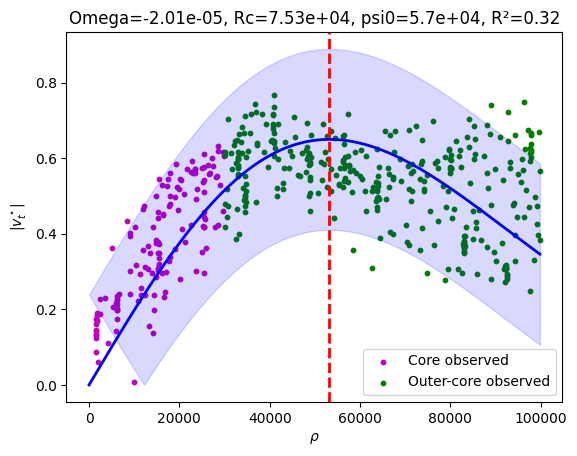

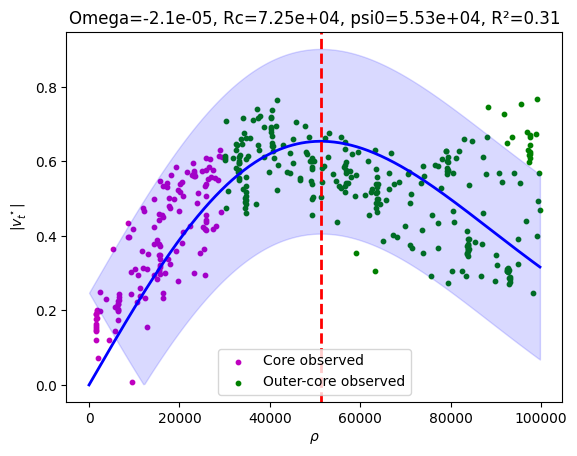

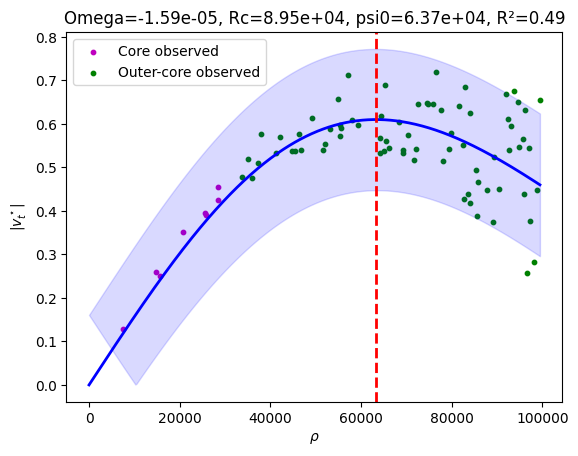

In [7]:
data_multi, df_xyuv_multi, df_rho_multi = latte_source_selector(source="multi", plot=True)
data_sadcp, df_xyuv_sadcp, _ = latte_source_selector(source="sadcp", plot=True)
data_sat, df_xyuv_sat, _ = latte_source_selector(source="sat", plot=True)

df_xyuv = pd.concat([df_xyuv_multi, df_xyuv_sadcp, df_xyuv_sat], ignore_index=True)
df_res = pd.concat([data_multi, data_sadcp, data_sat], ignore_index=True)
df_res


In [8]:
# Find R2
def model_uv_at_xy(xi, yi, xc, yc, Q, Omega, Rc):
    dx = xi - xc
    dy = yi - yc

    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    fac = Omega * np.exp(-rho2 / (Rc*Rc))

    uhat = -fac * (q12*dx + q22*dy)
    vhat =  fac * (q11*dx + q12*dy)

    return uhat, vhat
    
def vector_R2(u, v, uhat, vhat):
    m = np.isfinite(u) & np.isfinite(v) & np.isfinite(uhat) & np.isfinite(vhat)
    if not np.any(m):
        return np.nan
    u, v, uhat, vhat = u[m], v[m], uhat[m], vhat[m]
    err2 = (uhat - u)**2 + (vhat - v)**2
    u0, v0 = np.mean(u), np.mean(v)
    tot2 = (u - u0)**2 + (v - v0)**2
    return 1 - np.sum(err2)/np.sum(tot2) if np.sum(tot2) > 0 else np.nan
    
R2_vals = []
for (row, source) in zip([data_multi, data_sadcp, data_sat], ["multi", "sadcp", "sat"]):
    
    row = row.iloc[0]
    df = df_xyuv[df_xyuv.source == source]
    xi = df.xi.to_numpy(float)
    yi = df.yi.to_numpy(float)
    u  = df.ui.to_numpy(float)
    v  = df.vi.to_numpy(float)
    uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.Omega, row.Rc)
    R2_vals.append(vector_R2(u, v, uhat, vhat))

df_res['R2'] = R2_vals
df_res


,source,xc,yc,w,Q,Omega,Rc,psi0,time,alpha,R2
0,multi,-372.710283,-429.926759,-0.000041,"[[1.1445551540946677, -0.04665524335735116], [...",-0.000019,75275.588299,57008.984345,2023-10-19 16:27:30.509622172,1.152419,0.904916
1,sadcp,-630.462766,-698.395388,-0.000042,"[[1.1304059939390503, -0.052566977646175274], ...",-0.000020,72519.902965,55298.606920,2023-10-19 16:27:30.509622172,1.141277,0.894701
2,sat,3933.888475,5432.439575,-0.000033,"[[1.2364155209261036, 0.03289181268616171], [0...",-0.000015,89539.876755,63674.622816,2023-10-19 16:27:30.509622172,1.238936,0.966700


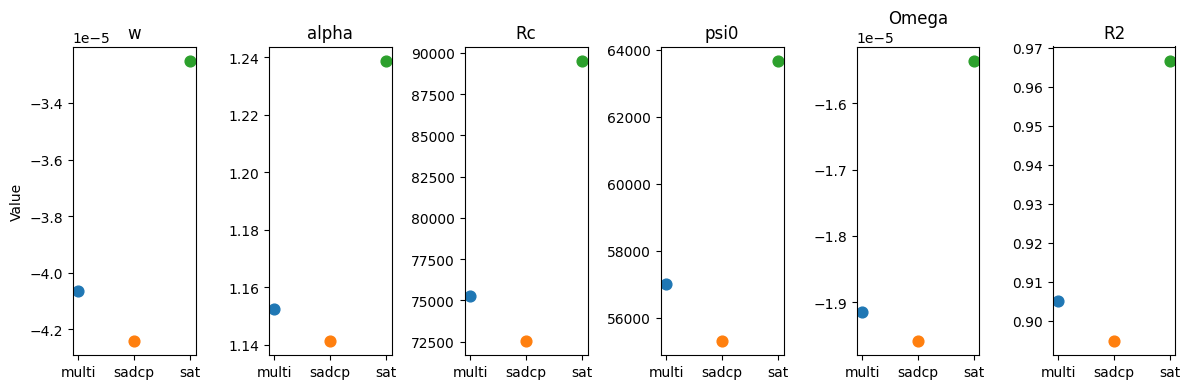

In [9]:
fig, axs = plt.subplots(1, 6, figsize=(12,4))

cols = ['w', 'alpha', 'Rc', 'psi0', 'Omega', 'R2']
colors = {"multi":"tab:blue", "sadcp":"tab:orange", "sat":"tab:green"}

for ax, c in zip(axs, cols):
    for k, row in df_res.iterrows():
        ax.scatter(row["source"], row[c], s=60, color=colors[row["source"]])
    ax.set_title(c)
axs[0].set_ylabel("Value")

plt.tight_layout()


In [10]:
sources = ["multi", "sadcp", "sat"]

U_all = []
V_all = []

X = ds_sat.x.values
Y = ds_sat.y.values
mask = ds_sat.land_mask.values

for s in sources:
    data = df_res[df_res.source == s].iloc[0]

    dx = X - data.xc
    dy = Y - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.Omega * np.exp(-rho2 / data.Rc**2)

    U = -fac * (q12*dx + q22*dy)
    V =  fac * (q11*dx + q12*dy)

    U = np.where(mask, np.nan, U)
    V = np.where(mask, np.nan, V)

    U_all.append(U)
    V_all.append(V)

U_all = np.stack(U_all)
V_all = np.stack(V_all)

t = np.array([np.datetime64(df_res.time.iloc[0])])

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("source","time","lat","lon"), U_all[:,None,:,:]),
        v=(("source","time","lat","lon"), V_all[:,None,:,:]),
    ),
    coords=dict(
        source=sources,
        time=t,
        lat=ds_sat.lat.values,
        lon=ds_sat.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
        land_mask=(("lat","lon"), mask),
    ),
)
ds_model


<xarray.Dataset> Size: 123kB
Dimensions:    (source: 3, time: 1, lat: 41, lon: 46)
Coordinates:
  * source     (source) <U5 60B 'multi' 'sadcp' 'sat'
  * time       (time) datetime64[us] 8B 2023-10-19T16:27:30.509622
  * lat        (lat) float64 328B -42.0 -41.8 -41.6 -41.4 ... -34.4 -34.2 -34.0
  * lon        (lon) float64 368B 149.0 149.2 149.4 149.6 ... 157.6 157.8 158.0
    x          (lat, lon) float64 15kB -4.642e+05 -4.467e+05 ... 3.241e+05
    y          (lat, lon) float64 15kB -4.551e+05 -4.551e+05 ... 4.329e+05
    land_mask  (lat, lon) bool 2kB False False False False ... False False False
Data variables:
    u          (source, time, lat, lon) float64 45kB -4.161e-31 ... 2.355e-15
    v          (source, time, lat, lon) float64 45kB 5.634e-31 ... -2.707e-15

In [11]:
# plot_model('sadcp', df_res, ds_sat, ds_model, df_xyuv, plot_data=True)
# plot_model('sat', df_res, ds_sat, ds_model, df_xyuv, plot_data=True)

### with fit

In [12]:
def plot_model_fit(df_rho, source, df_res, ds_sat, ds_model, df_xyuv, spac=1, scale=20,
                      xlim=(-170, 170), ylim=(-170, 170), out_thresh=False, plot_data=False):

    data = df_res[df_res.source == source].iloc[0]
    time = data.time

    sat = ds_sat.sel(time=time, method="nearest")
    mod = ds_model.sel(source=source).sel(time=time, method="nearest")#.squeeze("time")

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    dx, dy = sat.x.values - data.xc, sat.y.values - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)
    roi_quiv = roi & (rho2 >= 100_000**2)

    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)
    levels = np.arange(0, vmax+.05, .05)

    X_rho, Y_rho = np.meshgrid(np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100), np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100))
    dx = X_rho - data.xc
    dy = Y_rho - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    fig, axs = plt.subplots(1, 3, figsize=(16,5), constrained_layout=True) #sharex=True, sharey=True

    # Satellite
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")
    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale, alpha=.4, width=.0015)
    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
    axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[((data.Rc)**2)/2], colors="r", linewidths=2, linestyles="--")
    dsrc = df_res[df_res.source == source]
    axs[0].plot(dsrc.xc/1e3, dsrc.yc/1e3, color="r", lw=.5)
    if plot_data:
        df = df_xyuv.copy()
        df = df_xyuv[(df_xyuv.source==source)&(df_xyuv.core=='outer')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color='g', label='Outer-core data')
        df = df_xyuv[(df_xyuv.source==source)&(df_xyuv.core=='inner')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color='m', label='Core data')
    axs[0].set_title("Satellite"); axs[0].set_aspect("equal"); axs[0].legend(loc='lower right')

    # Model
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
    axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                  scale=scale, alpha=.5)
    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label='Eddy center')
    axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2, linestyles="--")
    axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color='r', label='Max tangential\nvelocity', ls='--')
    axs[1].set_title("Model - LATTE with S-ADCP and Satellite Data")
    axs[1].set_aspect("equal"); axs[1].legend(loc='lower right')

    gap = 20
    for ax in [axs[0], axs[1]]:
        # ax.axis('equal')
        ax.set_xlim(xlim[0]+gap, xlim[1]-gap)
        ax.set_ylim(ylim[0]+gap, ylim[1]-gap)
        ax.set_xlabel("x (km)")
        
        ax.set_ylabel("y (km)")

    axs[0].text(-0.1, 1.1, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    axs[1].text(-0.1, 1.1, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

    fig.colorbar(h1, ax=axs[1], label=r"Current speed (ms$^{-1}$)", fraction=0.05, pad=0.02)
    # if source == 'multi':
    #     fig.suptitle(f"time = {pd.to_datetime(time)}")
    # else:
    #     fig.suptitle(f"time = {pd.to_datetime(time)} | source = {source}")
    print(time)

    out_core_param_fit(df_rho.rho2/1e6, df_rho.Qr/1e3, df_rho.vt, Omega0=data.Omega, ax=axs[2], plot=True, km_flag=True, pred_flag=True)
    axs[2].set_title('')
    axs[2].set_xlabel(r'$\rho$ (km)')
    axs[2].set_ylabel(r'Normalised tangential velocity (ms$^{-1}$)')
    axs[2].text(-0.1, 1.1, "c)", transform=axs[2].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    
    plt.show()
    

2023-10-19 16:27:30.509622172


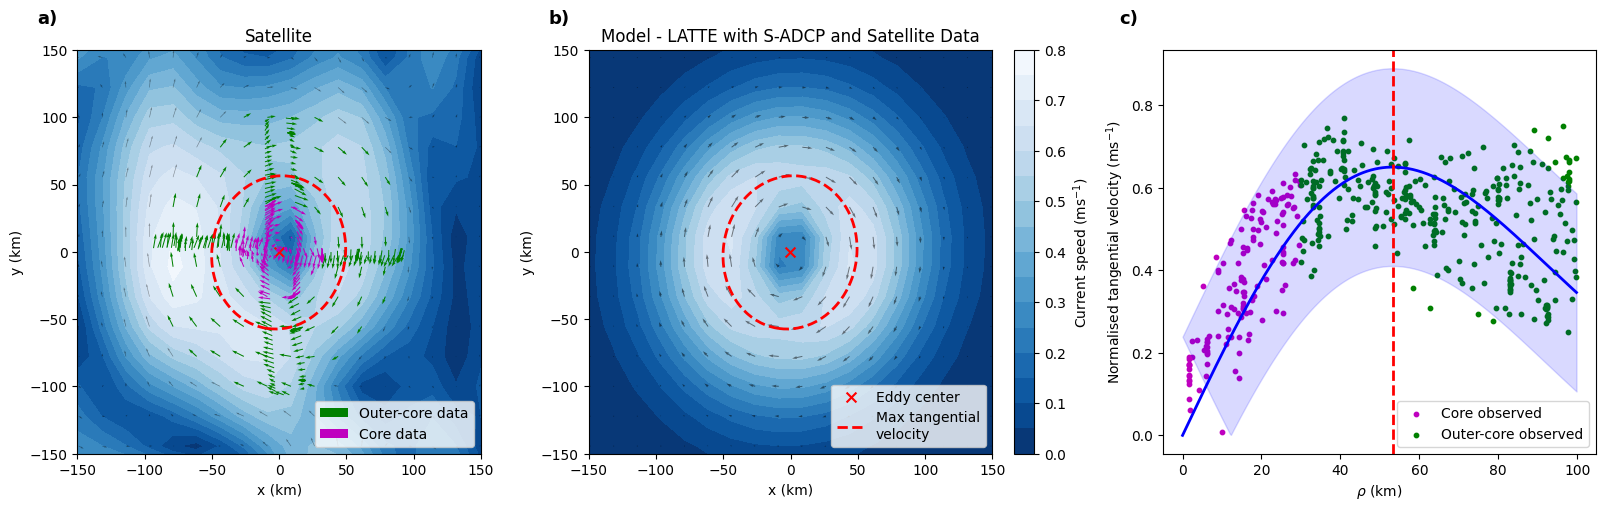

In [13]:
plot_model_fit(df_rho_multi, 'multi', df_res, ds_sat, ds_model, df_xyuv, plot_data=True)


In [14]:
df_paper = df_res.copy()
df_paper = df_paper.drop(columns='Q')
df_paper


,source,xc,yc,w,Omega,Rc,psi0,time,alpha,R2
0,multi,-372.710283,-429.926759,-0.000041,-0.000019,75275.588299,57008.984345,2023-10-19 16:27:30.509622172,1.152419,0.904916
1,sadcp,-630.462766,-698.395388,-0.000042,-0.000020,72519.902965,55298.606920,2023-10-19 16:27:30.509622172,1.141277,0.894701
2,sat,3933.888475,5432.439575,-0.000033,-0.000015,89539.876755,63674.622816,2023-10-19 16:27:30.509622172,1.238936,0.966700
